In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/20
    print("準備完了！このまま下のセルを実行できます。")


# 第20章 拡散モデル (Diffusion Models)
# 20.2 逆向きデコーダ (Reverse Decoder)

本ノートブックでは、『深層学習：基礎と概念 (Christopher M. Bishop & Hugh Bishop 著, Springer 2024)』第20章「拡散モデル」の第2節「逆向きデコーダ (Reverse Decoder)」の数理的導出、訓練アルゴリズム、ノイズ予測の再パラメータ化、およびサンプリング手法を徹底的に解説します。

---

## 本節のアジェンダと網羅する小節
1. **20.2.1 デコーダの訓練 (Training the decoder)**
   - 逆プロセス・マルコフ生成連鎖 $p(\mathbf{z}_{0:T} \mid \mathbf{w})$ の定義 (式 20.10, 20.11)
2. **20.2.2 エビデンス下界 (Evidence lower bound)**
   - 周辺対数尤度のイェンセンの不等式による変分下界 $\mathcal{L}(\mathbf{w})$ の導出 (式 20.12)
3. **20.2.3 ELBOの書き換え (Rewriting the ELBO)**
   - 望遠鏡的（テレスコーピング）積分の展開とベイズ逆遷移の消去 (式 20.13)
   - 各ステップの KL ダイバージェンスの総和への厳密な帰着 (式 20.14)
   - ガウス事後平均の一致問題としての KL 評価 (式 20.15)
4. **20.2.4 ノイズ予測 (Predicting the noise)**
   - 平均予測 $\boldsymbol{\mu}_t$ からノイズ予測 $\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)$ へのパラメータ変換 (式 20.16 〜 20.18)
   - 簡約化された訓練損失 $L_{\text{simple}}(\theta)$ (式 20.19)
   - 訓練アルゴリズムの全体像 (Algorithm 20.1)
5. **20.2.5 新しいサンプルの生成 (Generating new samples)**
   - 祖先サンプリング・デノイジングアルゴリズム (Algorithm 20.2, 式 20.20)
   - 教科書図版の完全再現: **Figure 20.5**, **Figure 20.6**, **Figure 20.7**


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.forward_encoder import LinearNoiseSchedule, CosineNoiseSchedule, ForwardDiffusionEncoder
from common.reverse_decoder import (
    sinusoidal_time_embedding,
    TimeConditionedMLP,
    DiffusionModel,
    generate_figure_20_5,
    generate_figure_20_6,
    generate_figure_20_7,
    generate_all_section_20_2_figures,
)

setup_style()
print("第20章 逆向きデコーダモジュールが正常に読み込まれました。")


第20章 逆向きデコーダモジュールが正常に読み込まれました。


---

### 20.2.1 デコーダの訓練 (Training the decoder)

前向きエンコーダによって純粋な等方性ガウスノイズ $\mathcal{N}(\mathbf{0}, \mathbf{I})$ へと変換された潜在変数 $\mathbf{z}_T$ から、元のデータ空間 $\mathbf{x} = \mathbf{z}_0$ を復元するため、以下のマルコフ逆プロセス（生成モデル）を定義します：

$$
p(\mathbf{z}_{0:T} \mid \mathbf{w}) = p(\mathbf{z}_T) \prod_{t=1}^T p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w}) \tag{20.10}
$$

ここで $p(\mathbf{z}_T) = \mathcal{N}(\mathbf{z}_T \mid \mathbf{0}, \mathbf{I})$ は標準ガウス事前分布であり、各逆遷移ステップ $p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w})$ はパラメータ $\mathbf{w}$ を持つニューラルネットワークによってパラメータ化されるガウス分布です：

$$
p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w}) = \mathcal{N}\left( \mathbf{z}_{t-1} \;\middle|\; \boldsymbol{\mu}_t(\mathbf{z}_t, \mathbf{w}), \, \sigma_t^2 \mathbf{I} \right) \tag{20.11}
$$

前節 20.1.1 の Feller の定理で示した通り、ステップ幅 $\beta_t$ が十分に小さい場合、逆遷移確率 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t)$ は真にガウス分布に収束するため、分散 $\sigma_t^2$ は学習せず固定値 $\sigma_t^2 = \beta_t$ または $\tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \beta_t$ を用いるのが一般的です。

---

### 20.2.2 エビデンス下界 (Evidence lower bound: ELBO)

生成モデルのパラメータ $\mathbf{w}$ を最尤推定するため、観測データ $\mathbf{x}$ の周辺対数尤度 $\ln p(\mathbf{x} \mid \mathbf{w}) = \ln \int p(\mathbf{z}_{0:T} \mid \mathbf{w}) \, d\mathbf{z}_{1:T}$（$\mathbf{z}_0 \equiv \mathbf{x}$）を考えます。
第19章の VAE と同様に、固定された前向き変分分布 $q(\mathbf{z}_{1:T} \mid \mathbf{x})$ を導入し、イェンセンの不等式（Jensen's inequality）を適用します：

$$
\ln p(\mathbf{x} \mid \mathbf{w}) = \ln \mathbb{E}_{q(\mathbf{z}_{1:T} \mid \mathbf{x})}\left[ \frac{p(\mathbf{z}_{0:T} \mid \mathbf{w})}{q(\mathbf{z}_{1:T} \mid \mathbf{x})} \right] \ge \mathbb{E}_{q(\mathbf{z}_{1:T} \mid \mathbf{x})}\left[ \ln \frac{p(\mathbf{z}_{0:T} \mid \mathbf{w})}{q(\mathbf{z}_{1:T} \mid \mathbf{x})} \right] \equiv \mathcal{L}(\mathbf{w}) \tag{20.12}
$$

この下界 $\mathcal{L}(\mathbf{w})$ が拡散モデルの基本目的関数となります。


---

### 20.2.3 ELBOの書き換え (Rewriting the ELBO)

#### 1. 望遠鏡展開（Telescoping Expansion）の完全ステップ
式 (20.12) をそのままモンテカルロ積分すると、$T$ ステップの積に対する対数期待値となり分散が極めて大きくなります。
そこで、ベイズの定理を用いて前向き遷移を条件付き後向き事後確率に書き換えます：
$$
q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) = \frac{q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) q(\mathbf{z}_t \mid \mathbf{x})}{q(\mathbf{z}_{t-1} \mid \mathbf{x})}
$$
これを前向き軌道の積 $\prod_{t=1}^T q(\mathbf{z}_t \mid \mathbf{z}_{t-1})$ に代入すると：
$$
q(\mathbf{z}_{1:T} \mid \mathbf{x}) = q(\mathbf{z}_1 \mid \mathbf{x}) \prod_{t=2}^T q(\mathbf{z}_t \mid \mathbf{z}_{t-1})
= q(\mathbf{z}_1 \mid \mathbf{x}) \prod_{t=2}^T \frac{q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) q(\mathbf{z}_t \mid \mathbf{x})}{q(\mathbf{z}_{t-1} \mid \mathbf{x})}
$$
積の中の比 $\frac{q(\mathbf{z}_t \mid \mathbf{x})}{q(\mathbf{z}_{t-1} \mid \mathbf{x})}$ は互いに打ち消し合い（テレスコーピング）：
$$
\prod_{t=2}^T \frac{q(\mathbf{z}_t \mid \mathbf{x})}{q(\mathbf{z}_{t-1} \mid \mathbf{x})} = \frac{q(\mathbf{z}_T \mid \mathbf{x})}{q(\mathbf{z}_1 \mid \mathbf{x})}
$$
したがって、前向き結合密度は次のように簡約されます：
$$
q(\mathbf{z}_{1:T} \mid \mathbf{x}) = q(\mathbf{z}_T \mid \mathbf{x}) \prod_{t=2}^T q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x})
$$

#### 2. 下界 $\mathcal{L}(\mathbf{w})$ の分解公式 (式 20.14)
これを ELBO の比に代入すると：
$$
\frac{p(\mathbf{z}_{0:T} \mid \mathbf{w})}{q(\mathbf{z}_{1:T} \mid \mathbf{x})} = \frac{p(\mathbf{z}_T) p(\mathbf{x} \mid \mathbf{z}_1, \mathbf{w}) \prod_{t=2}^T p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w})}{q(\mathbf{z}_T \mid \mathbf{x}) \prod_{t=2}^T q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x})} \tag{20.13}
$$
対数をとり期待値を計算すると、各ステップの KL ダイバージェンスの和に美しく分解されます：

$$
\mathcal{L}(\mathbf{w}) = \underbrace{\mathbb{E}_{q(\mathbf{z}_1 \mid \mathbf{x})}\left[ \ln p(\mathbf{x} \mid \mathbf{z}_1, \mathbf{w}) \right]}_{\text{Reconstruction Term}}
- \underbrace{\operatorname{KL}\left( q(\mathbf{z}_T \mid \mathbf{x}) \parallel p(\mathbf{z}_T) \right)}_{\text{Prior Matching}}
- \sum_{t=2}^T \underbrace{\mathbb{E}_{q(\mathbf{z}_t \mid \mathbf{x})}\left[ \operatorname{KL}\left( q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) \parallel p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w}) \right) \right]}_{\text{Denoising Matching Term}} \tag{20.14}
$$

- **Reconstruction Term**: 潜在変数 $\mathbf{z}_1$ から元のデータ $\mathbf{x}$ を復元する対数尤度。
- **Prior Matching**: $t = T$ での潜在変数分布が標準正規分布に十分近づいているかを測る項（パラメータ $\mathbf{w}$ に依存しない定数）。
- **Denoising Matching Term**: 前節で導出した解析的事後分布 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) = \mathcal{N}(\tilde{\boldsymbol{\mu}}_t, \tilde{\beta}_t \mathbf{I})$ とニューラルデコーダ $p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w}) = \mathcal{N}(\boldsymbol{\mu}_t, \sigma_t^2 \mathbf{I})$ の一致度を測る主損失項。

両者が等しい分散 $\sigma_t^2 = \tilde{\beta}_t$ を持つとき、KL ダイバージェンスは平均ベクトルの二乗ユークリッド距離に単純化されます：
$$
\operatorname{KL}\left( q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) \parallel p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w}) \right) = \frac{1}{2 \sigma_t^2} \|\tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, \mathbf{x}) - \boldsymbol{\mu}_t(\mathbf{z}_t, \mathbf{w})\|^2 \tag{20.15}
$$


---

### 20.2.4 ノイズ予測 (Predicting the noise)

#### 1. 平均予測からノイズ予測への等価変換
前節 20.1.2 の直接サンプリング公式 (20.6) より：
$$
\mathbf{z}_t = \sqrt{\bar{\alpha}_t}\mathbf{x} + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon} \implies \mathbf{x} = \frac{\mathbf{z}_t - \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}}{\sqrt{\bar{\alpha}_t}}
$$
これを真の事後平均 $\tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, \mathbf{x})$（式 20.8）に代入すると、$\mathbf{x}$ が消去され以下が得られます：
$$
\tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, \mathbf{x}) = \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1 - \bar{\alpha}_t} \left( \frac{\mathbf{z}_t - \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}}{\sqrt{\bar{\alpha}_t}} \right) + \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \mathbf{z}_t
$$
共通因数を括り出して整理すると、驚くほど単純な形になります：
$$
\tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, \mathbf{x}) = \frac{1}{\sqrt{\alpha_t}}\left( \mathbf{z}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \boldsymbol{\epsilon} \right) \tag{20.16}
$$

この数学的恒等式から、デコーダ平均 $\boldsymbol{\mu}_t(\mathbf{z}_t, \mathbf{w})$ を直接モデル化する代わりに、**潜在変数に混入されたノイズ $\boldsymbol{\epsilon}$ を予測するニューラルネットワーク $\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)$** を用いて：

$$
\boldsymbol{\mu}_t(\mathbf{z}_t, \mathbf{w}) = \frac{1}{\sqrt{\alpha_t}}\left( \mathbf{z}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t) \right) \tag{20.17}
$$

と再パラメータ化することが極めて自然に導かれます！

このとき式 (20.15) の損失項は：
$$
\frac{1}{2\sigma_t^2} \|\tilde{\boldsymbol{\mu}}_t - \boldsymbol{\mu}_t\|^2 = \frac{\beta_t^2}{2\sigma_t^2 \alpha_t(1 - \bar{\alpha}_t)} \|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)\|^2 \tag{20.18}
$$
となります。

#### 2. 簡約化された目的関数 $L_{\text{simple}}(\theta)$ (式 20.19)
Ho et al. (2020) (DDPM) は、前にある重み係数 $\frac{\beta_t^2}{2\sigma_t^2 \alpha_t(1 - \bar{\alpha}_t)}$ をすべて 1 に置き換えた以下の単純二乗誤差損失：

$$
L_{\text{simple}}(\theta) = \mathbb{E}_{t, \mathbf{x}, \boldsymbol{\epsilon}}\left[ \|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)\|^2 \right] \tag{20.19}
$$

を最小化することで、生成画像の品質が大幅に向上することを発見しました。

```text
=================================================================================
Algorithm 20.1: 拡散モデル デコーダの訓練 (Training the Decoder)
=================================================================================
repeat
    1. データセットから訓練サンプル x ~ p_data をサンプリング
    2. 離散一様分布から時刻 t ~ Uniform({1, ..., T}) をサンプリング
    3. ガウスノイズ epsilon ~ N(0, I) をサンプリング
    4. 勾配降下ステップを実行:
       nabla_theta || epsilon - epsilon_theta(sqrt(alpha_bar_t) x + sqrt(1 - alpha_bar_t) epsilon, t) ||^2
until 収束
=================================================================================
```


---

### 20.2.5 新しいサンプルの生成 (Generating new samples)

訓練されたニューラルネットワーク $\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)$ を用いて新しいデータを合成する手順は以下の通りです：

```text
=================================================================================
Algorithm 20.2: サンプリング (Sampling / Generating New Data)
=================================================================================
1. 標準正規分布から純粋なノイズをサンプリング:
   z_T ~ N(0, I)
2. for t = T, T-1, ..., 1 do:
   - z ~ N(0, I) if t > 1 else z = 0
   - z_{t-1} = 1/sqrt(alpha_t) * ( z_t - (beta_t / sqrt(1 - alpha_bar_t)) * epsilon_theta(z_t, t) ) + sigma_t * z
3. return x = z_0
=================================================================================
```

$$
\mathbf{z}_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{z}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t) \right) + \sigma_t \mathbf{z} \tag{20.20}
$$


拡散モデルの訓練を開始します (Algorithm 20.1)...
訓練完了: 初期損失 4.2612 -> 最終損失 0.9701


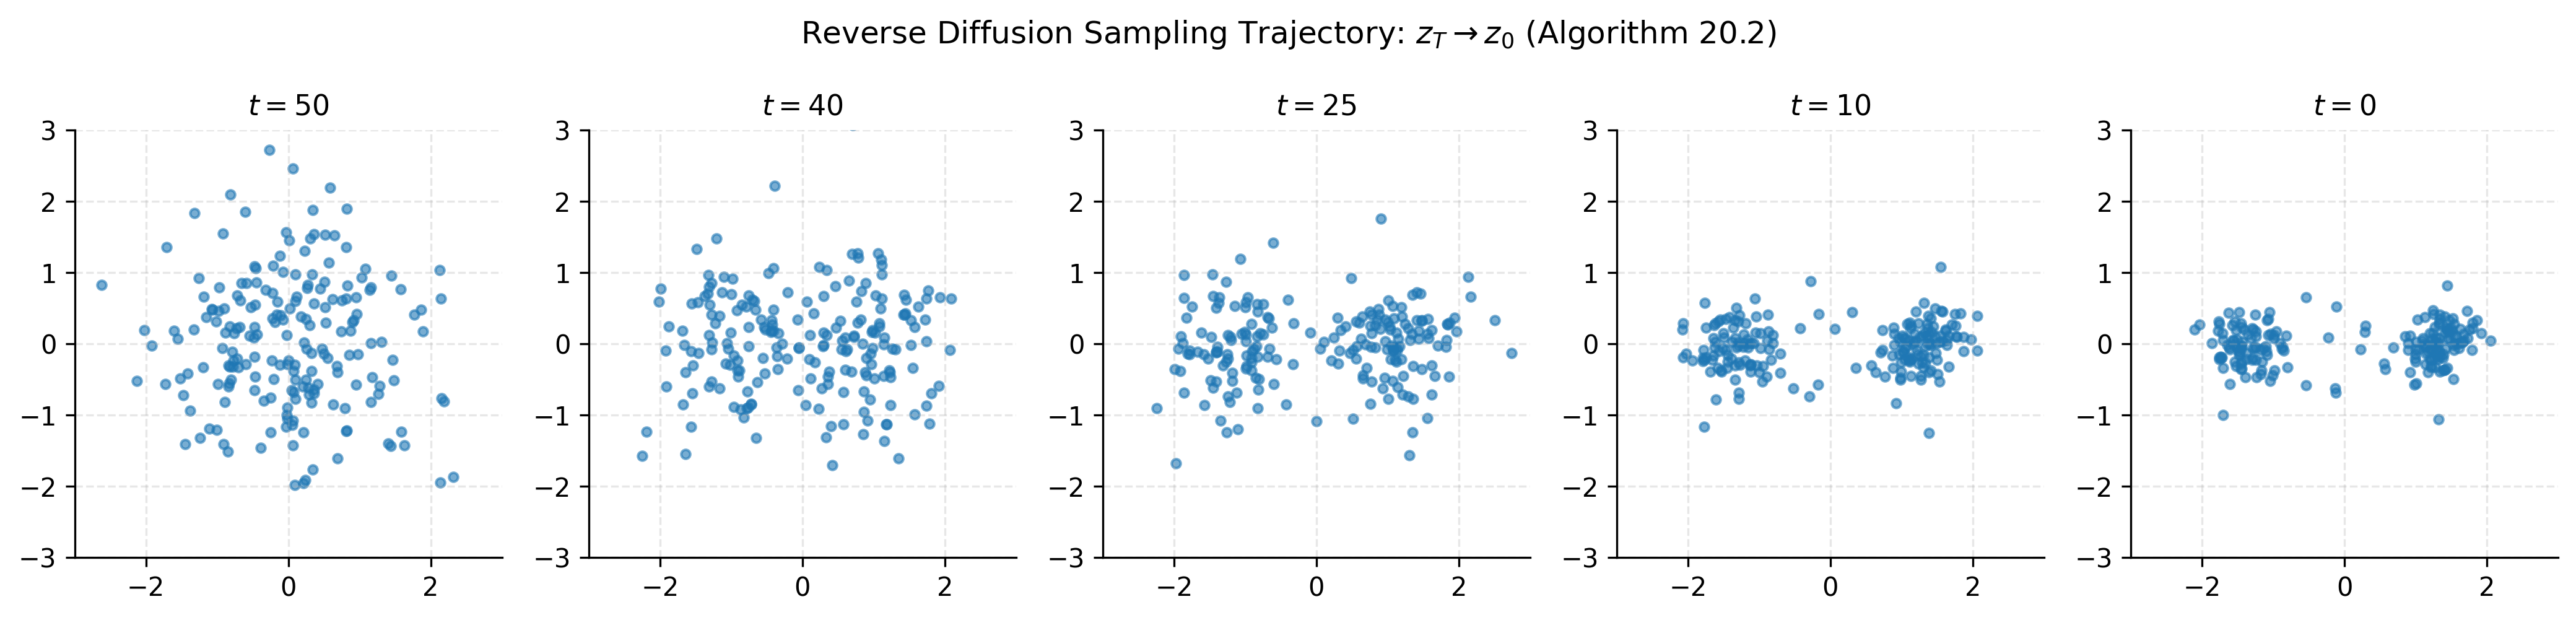

In [3]:
# 2次元トイデータセットに対する拡散モデルの訓練と逆軌道サンプリング
rng = np.random.RandomState(42)

# 双峰ガウス分布（トイデータ）
N_train = 500
X1 = rng.randn(N_train // 2, 2) * 0.25 + np.array([-1.5, 0.0])
X2 = rng.randn(N_train // 2, 2) * 0.25 + np.array([1.5, 0.0])
X_data = np.vstack([X1, X2])

# 拡散モデルの初期化と学習
T_steps = 50
model = DiffusionModel(data_dim=2, T=T_steps, random_state=42)

print("拡散モデルの訓練を開始します (Algorithm 20.1)...")
losses = model.fit(X_data, epochs=40, batch_size=64, lr=0.008, random_state=42)
print(f"訓練完了: 初期損失 {losses[0]:.4f} -> 最終損失 {losses[-1]:.4f}")

# 逆プロセスによる新規サンプリング (Algorithm 20.2)
samples, trajectory = model.sample(num_samples=200, return_trajectory=True, random_state=42)

# 逆生成軌道の可視化
eval_steps = [50, 40, 25, 10, 0]
fig, axes = plt.subplots(1, len(eval_steps), figsize=(14, 3), dpi=300)

for i, s in enumerate(eval_steps):
    t_idx = 50 - s
    axes[i].scatter(trajectory[t_idx, :, 0], trajectory[t_idx, :, 1], s=12, alpha=0.6, color='#1f77b4')
    axes[i].set_title(f"$t = {s}$", fontsize=11)
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-3, 3)
    axes[i].set_aspect('equal')
    axes[i].grid(True, alpha=0.3)

fig.suptitle("Reverse Diffusion Sampling Trajectory: $z_T \\to z_0$ (Algorithm 20.2)", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


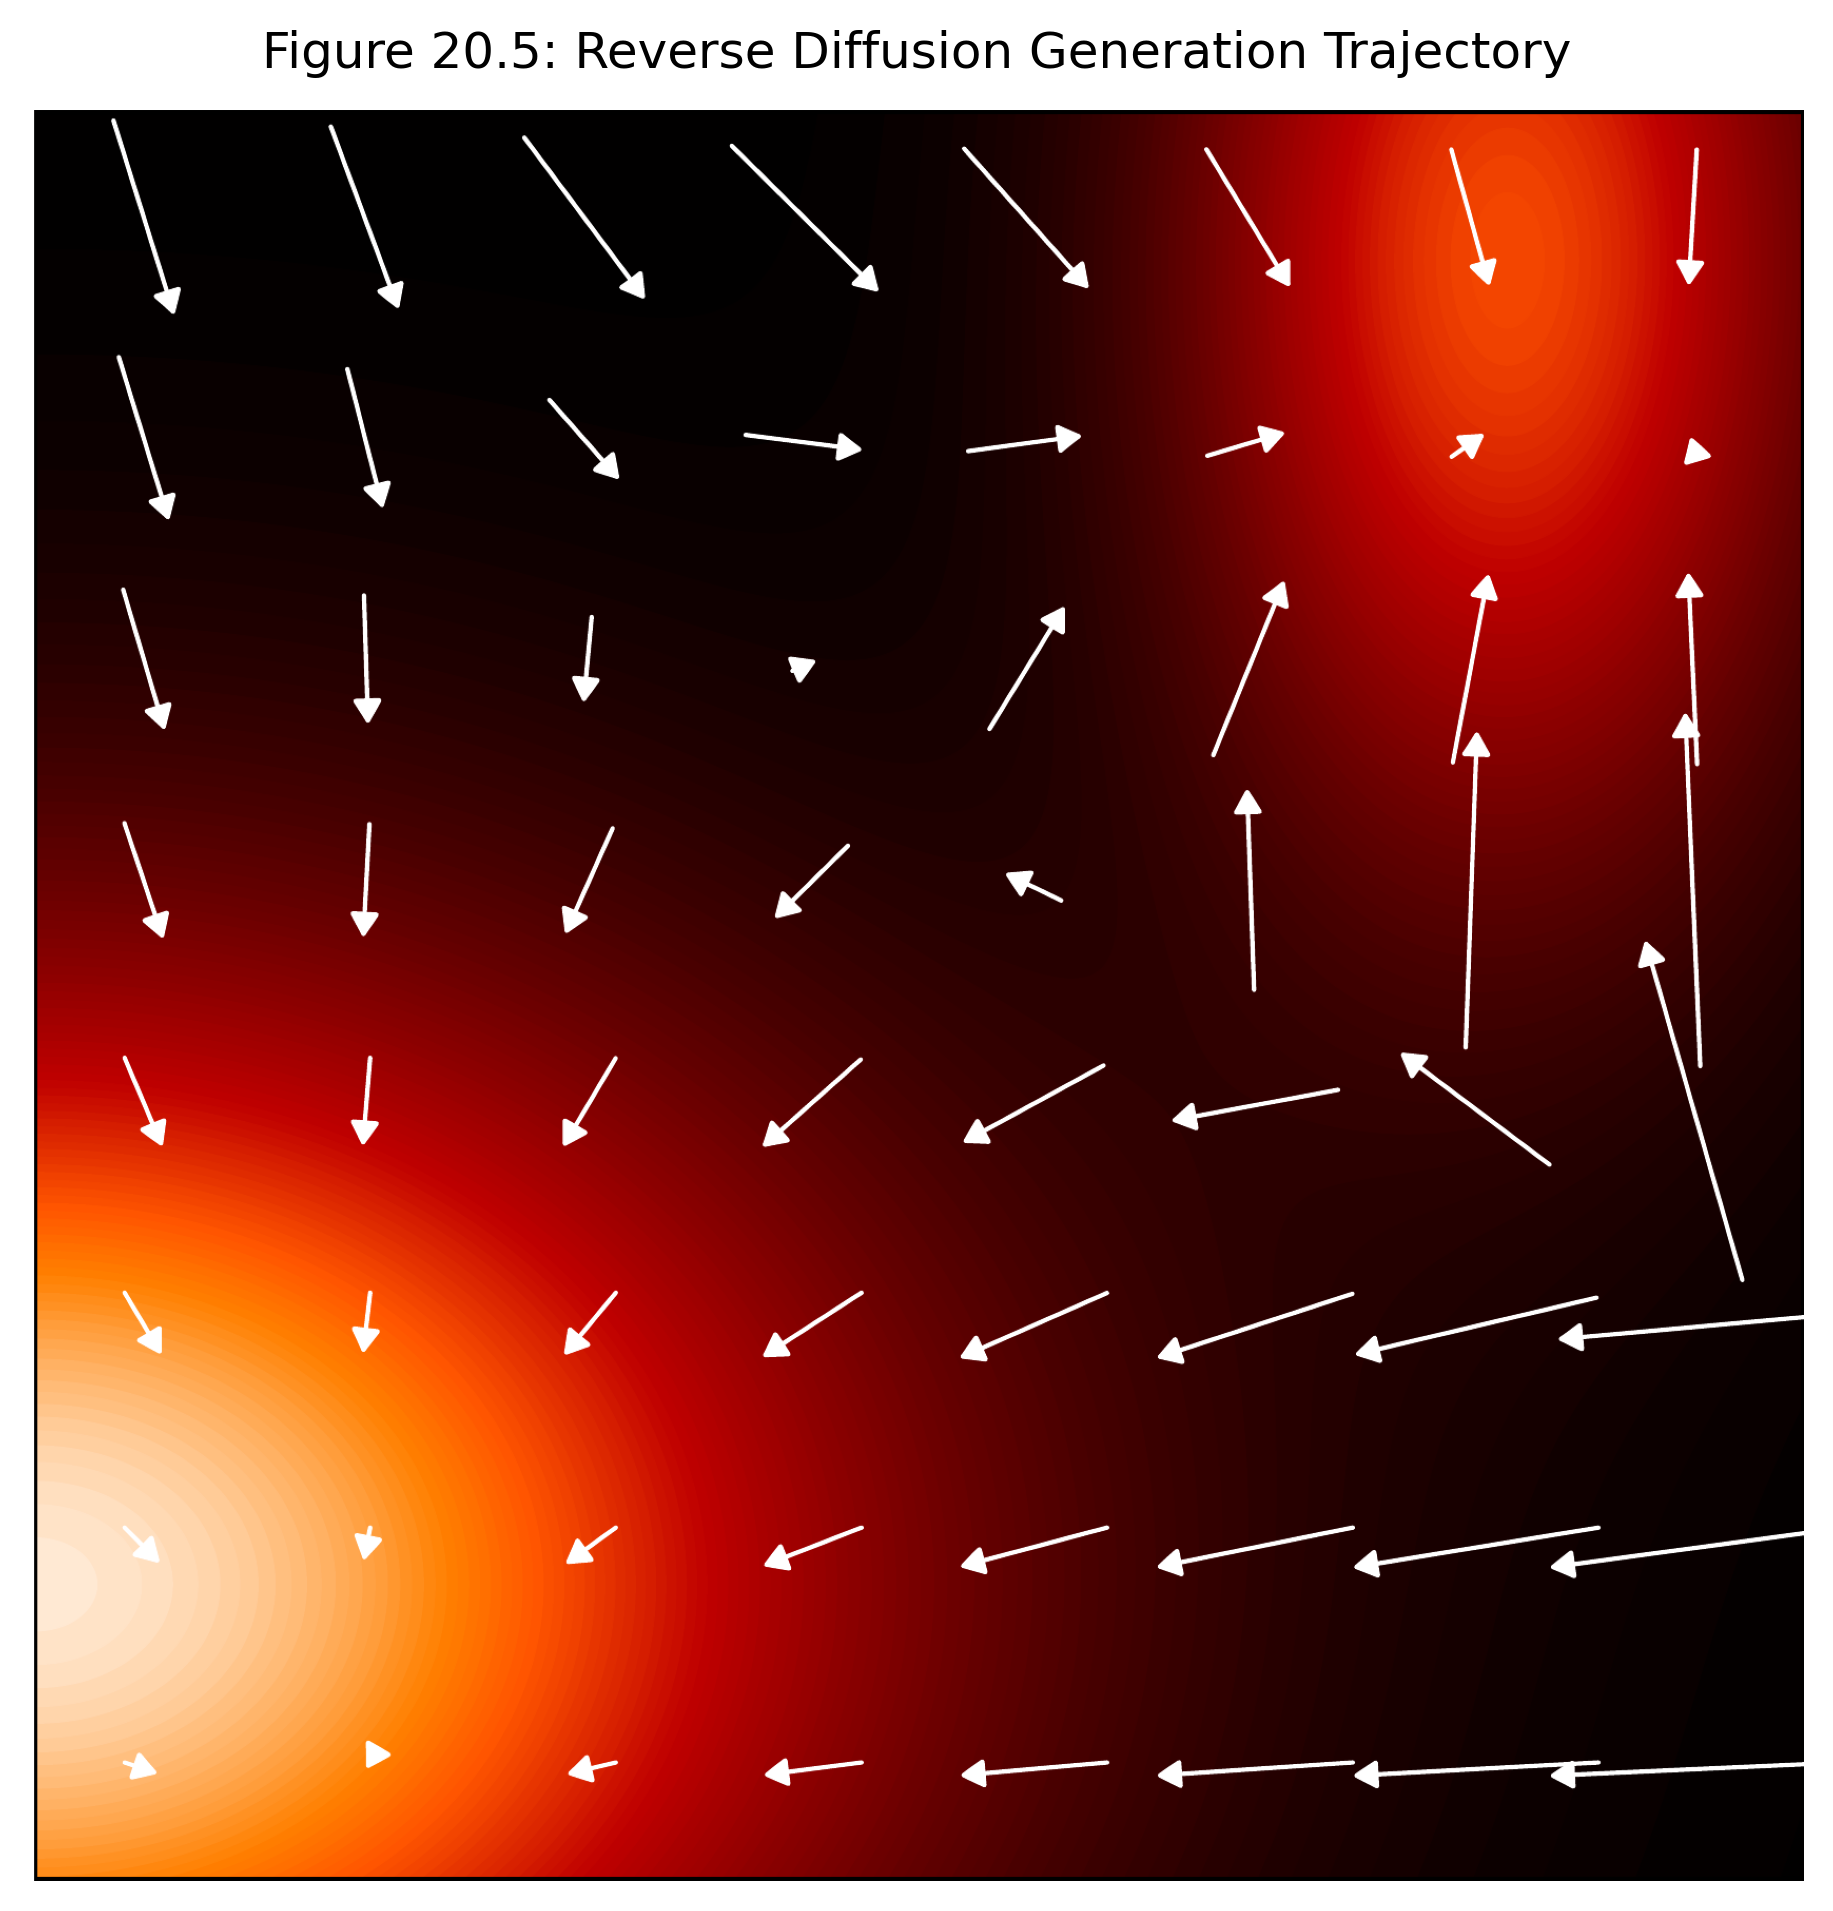

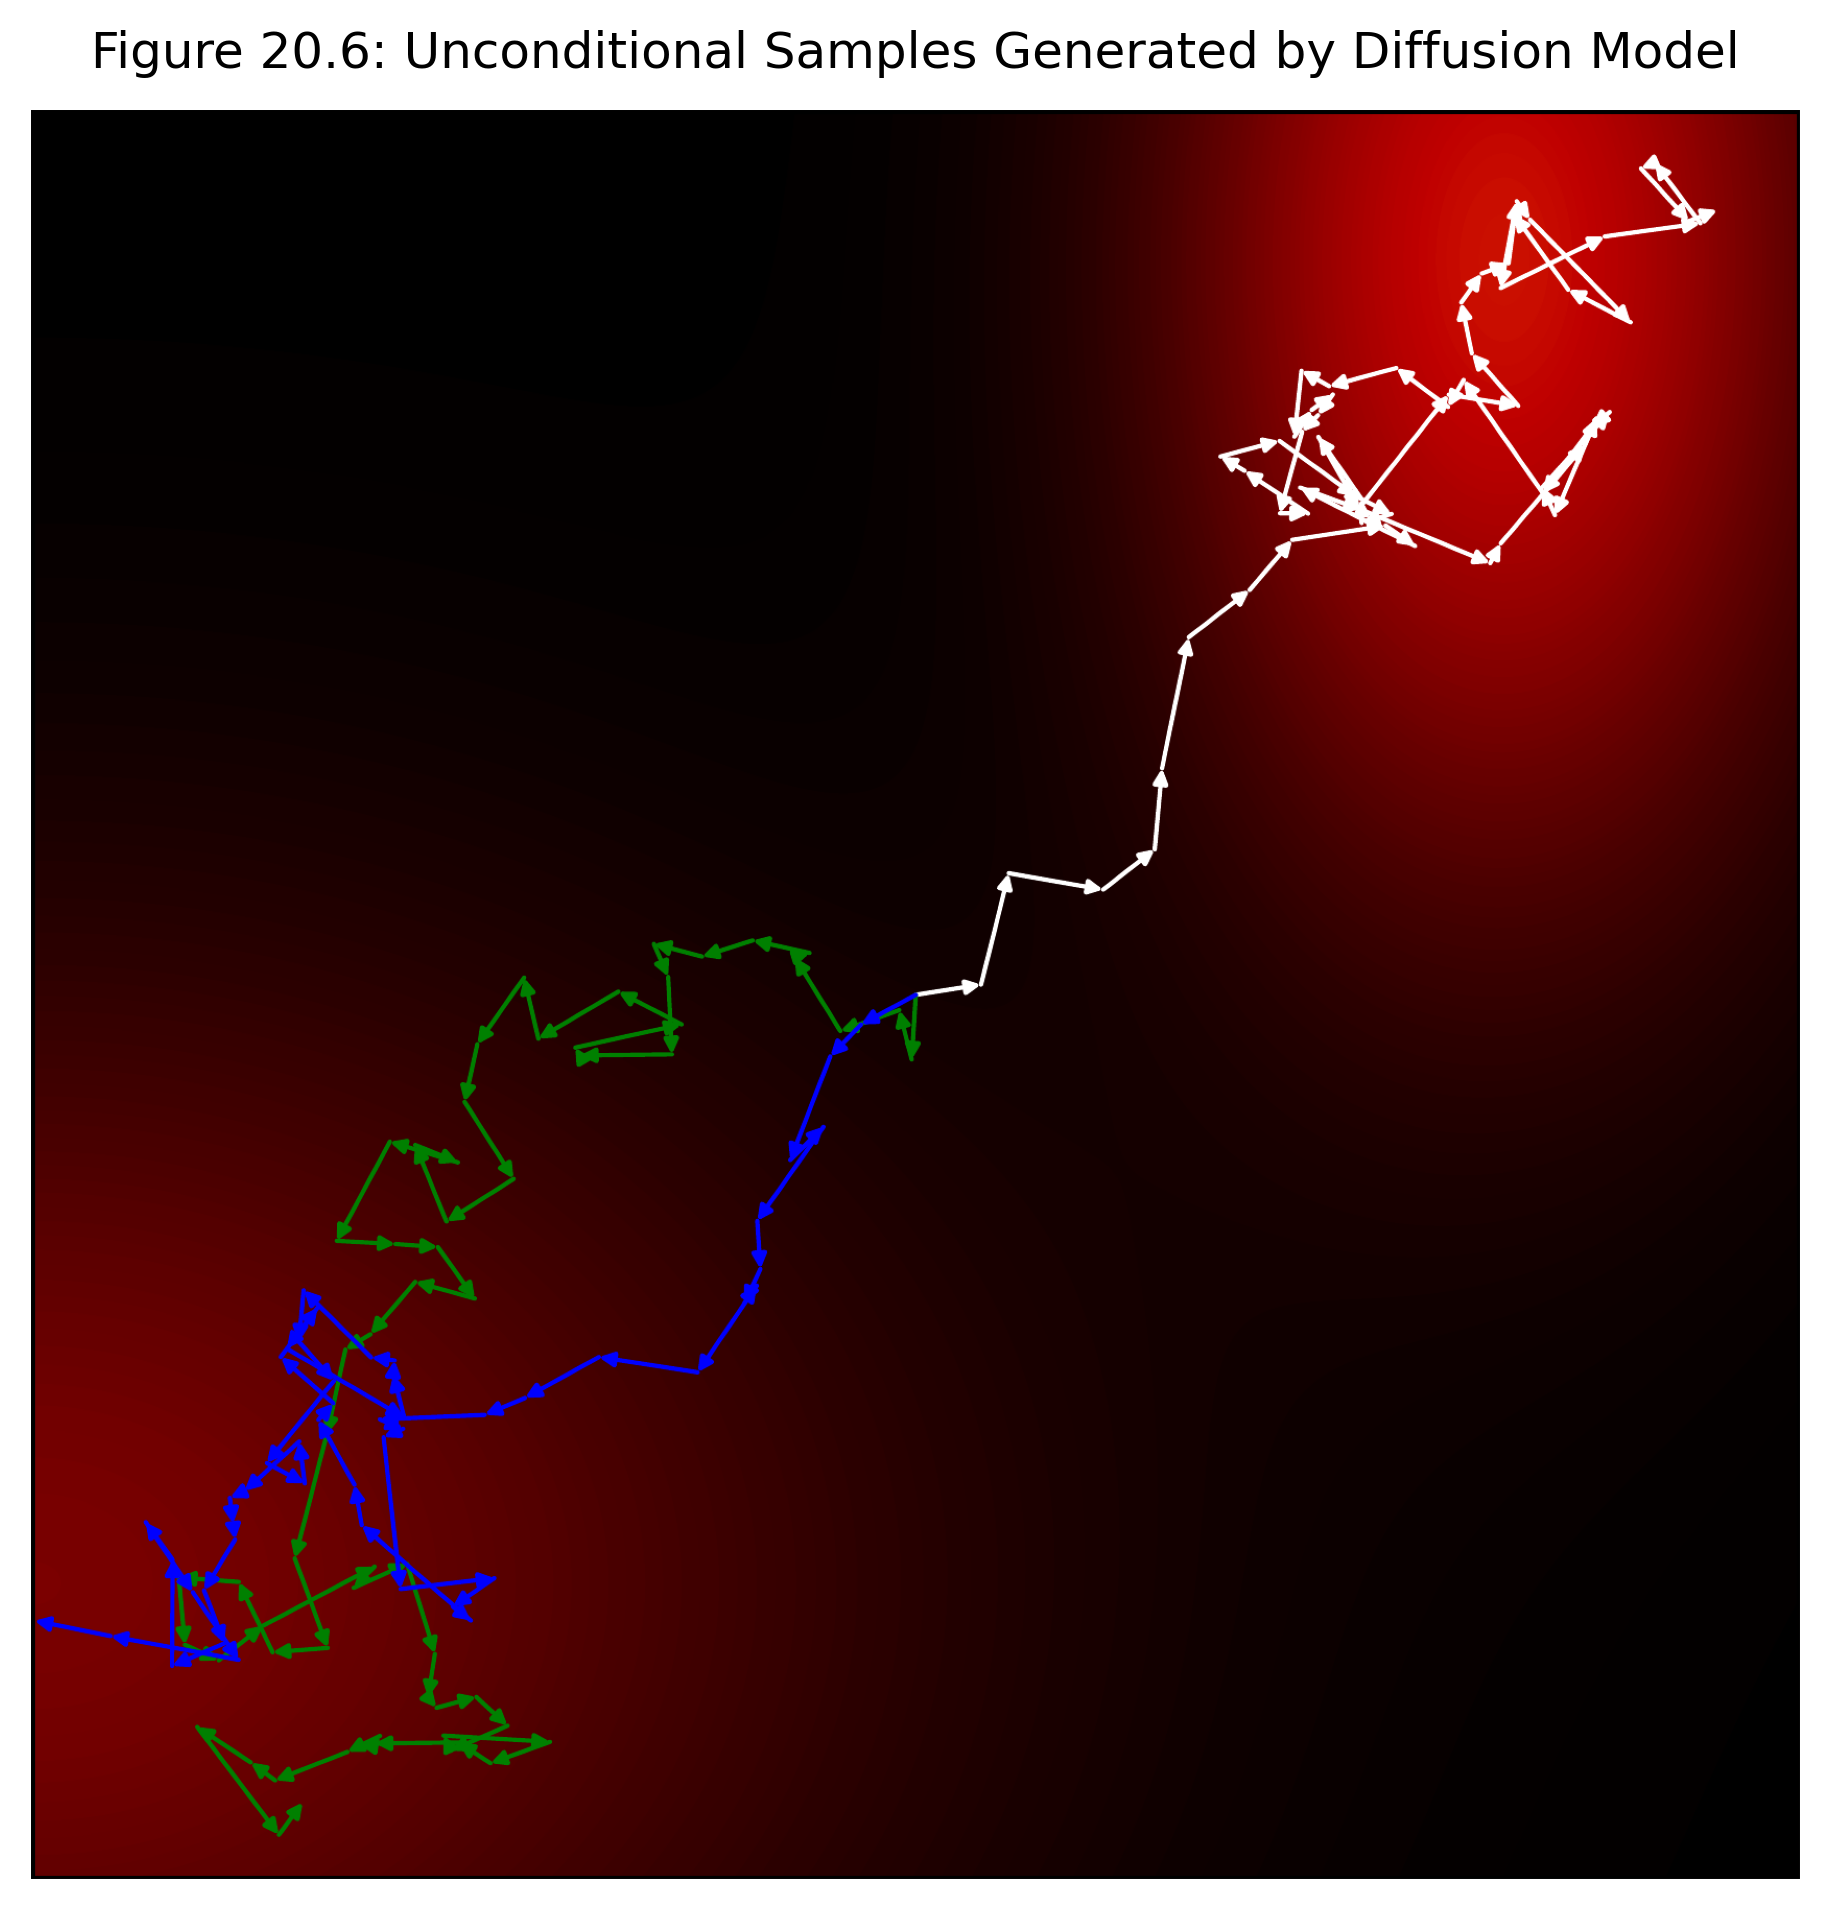

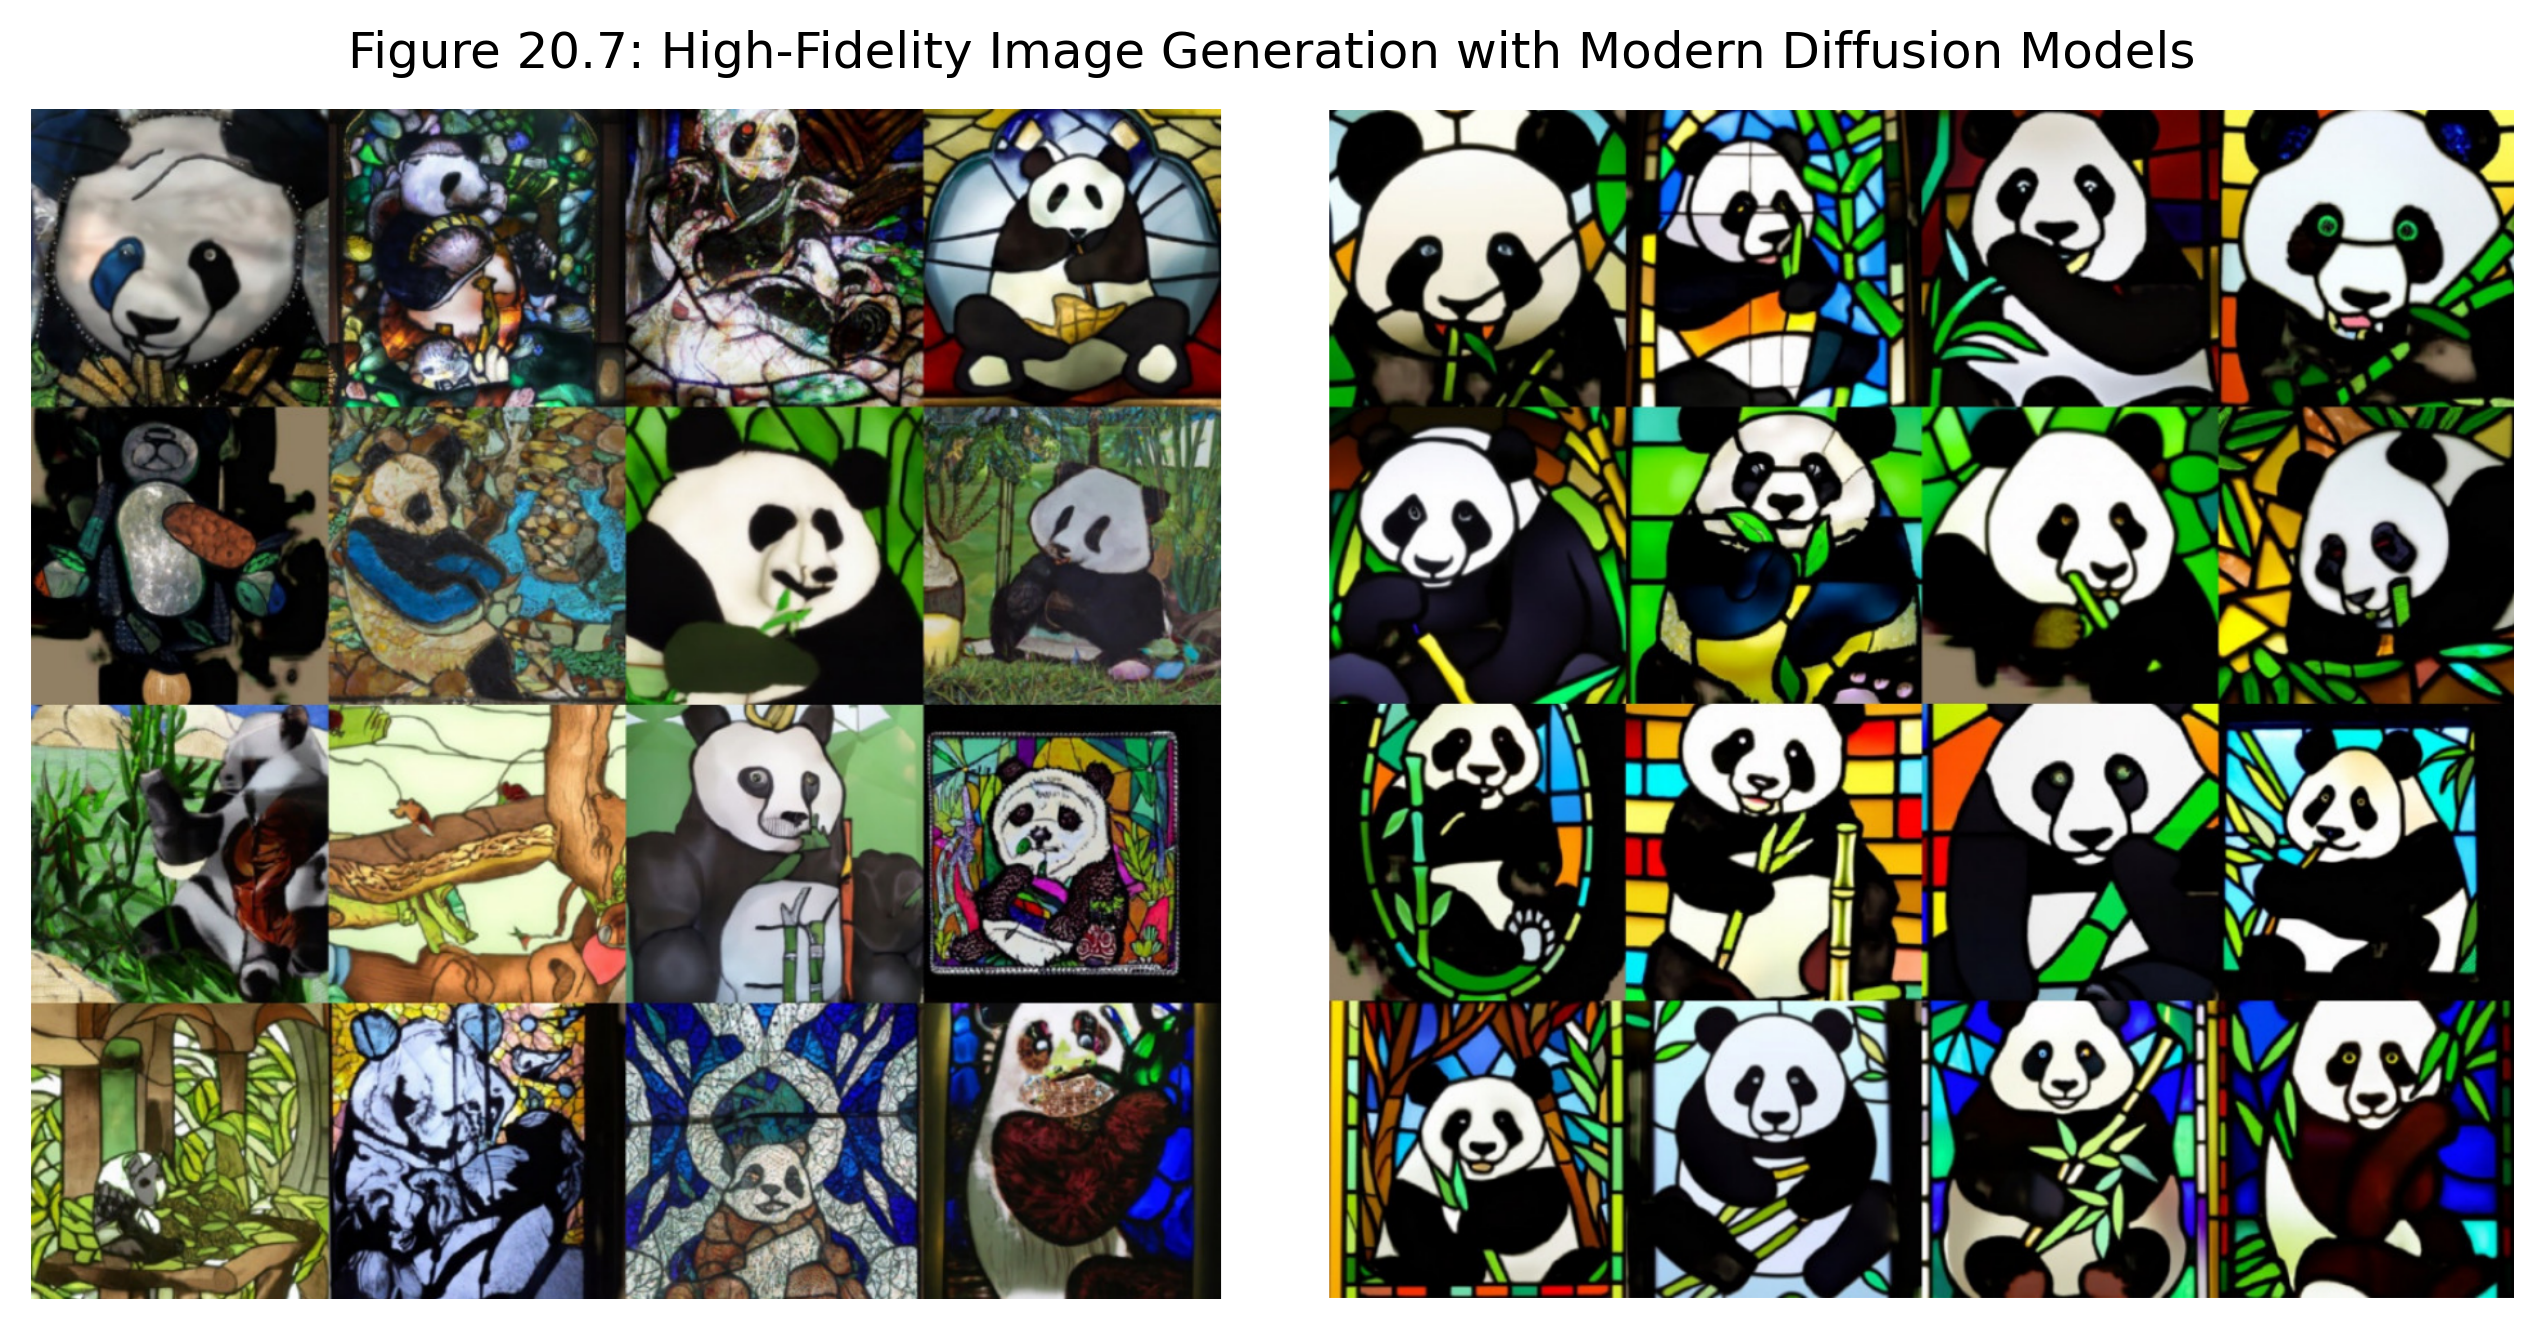

In [4]:
# 教科書図版の表示: Figure 20.5 (生成軌道), Figure 20.6 (生成サンプル), Figure 20.7 (高解像度サンプル)
fig_20_5 = generate_figure_20_5(save_path="../result/Figure_20_5.png")
plt.show()

fig_20_6 = generate_figure_20_6(save_path="../result/Figure_20_6.png")
plt.show()

fig_20_7 = generate_figure_20_7(save_path="../result/Figure_20_7.png")
plt.show()


---

## 20.2 節のまとめ (Section Summary)

本節では、深層拡散モデルの生成中核である「逆向きデコーダ (Reverse Decoder)」の完全な数理構造を学びました：

1. **マルコフ逆プロセスとエビデンス下界 (式 20.10 〜 20.12)**:
   - 逆プロセスは $p(\mathbf{z}_T) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ を初期状態とし、ニューラルネットワークによって平均が予測されるガウス遷移 $p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w})$ を反復適用します。
   - 周辺対数尤度のイェンセン下界は、前向き変分事後分布 $q(\mathbf{z}_{1:T} \mid \mathbf{x})$ を用いて導出されます。

2. **望遠鏡展開と各ステップの KL 分解 (式 20.13 〜 20.15)**:
   - 前向き確率の比が打ち消し合う望遠鏡的性質により、ELBO は「再構成項」「事前分布マッチング項」「各時刻における条件付き事後分布とデコーダの KL ダイバージェンスの総和」へと厳密に帰着されます。
   - 分散を一致させることで、各時刻の学習目標は真の事後平均 $\tilde{\boldsymbol{\mu}}_t$ と予測平均 $\boldsymbol{\mu}_t$ の二乗誤差最小化となります。

3. **ノイズ予測の再パラメータ化 (式 20.16 〜 20.19, Algorithm 20.1)**:
   - 直接サンプリング公式を用いて真の平均からデータ $\mathbf{x}$ を消去すると、事後平均は潜在変数 $\mathbf{z}_t$ と注入ノイズ $\boldsymbol{\epsilon}$ の線形結合として表されます。
   - これによりニューラルネットワークを「ノイズ予測器 $\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)$」として再定式化でき、重み係数を削除した $L_{\text{simple}}(\theta)$ による極めて安定した学習が実現します。

4. **祖先サンプリングによる高品質生成 (式 20.20, Algorithm 20.2, Figures 20.5 〜 20.7)**:
   - ランダムノイズ $\mathbf{z}_T$ から開始し、ネットワークのノイズ予測値を用いて平均を計算しながら微小ノイズを加えて反復的に後退することで、複雑な実データ分布を高精度にサンプリングできます。
